<a href="https://colab.research.google.com/github/davidlealo/tarea_1_sisrec_2026/blob/main/SISREC_2026_PUC_T1_YAHOO_MUSIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 Sistemas de Recomendación 2026
### Grupo 26
#### Análisis Yahoo! Music

*   Marcelo Vargas
*   David Leal

Reinstalar numpy para poder trabajar con Surprise

In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 98.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
tobl

Carga de la biblioteca

In [1]:
!pip install scikit-surprise --no-build-isolation --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2708543 sha256=8af6a3755bf4800f84ff7620a413de5b7685ec4b94ca2934aba9676e424178a6
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


# Error con la versióin de numpy y solución

Estuve hablando con Gemini (https://gemini.google.com/share/0593148d28a8) y al bajar la versión de Numpy para usar Surprise hay problemas con algunos archivos, entonces estoy armando otra versión de este código solamente con los temas de Yahoo Music.

Cuando comencé a hacer el análisis de datos lo hice directo sin tomar en cuenta que Surprise necesitaba otra versión de numpy, entonces luego como quedé con ese problema tuve que hacer un cambio, inicialmente:

```python
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)

df_train_wiki = pd.read_csv(get_url("wikimedia_train.csv"))
df_val_wiki = pd.read_csv(get_url("wikimedia_validation.csv"))


def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)

image_embeddings = load_remote_npy("wikimedia_image_embeddings.npy")
item_id_to_idx = load_remote_npy("wikimedia_item_id_to_idx.npy").item()

print("¡Datos cargados exitosamente!")

```


Ahora:

In [77]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)



def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)


print("¡Datos cargados exitosamente de Música!")

¡Datos cargados exitosamente de Música!


## Análisis del set de datos: `df_artists`
Para analizar esto analizaré primero la cantidad de artístas únicos y géneros únicos, además de contar la cantidad de géneros distintos


In [78]:
artistas_unicos = df_artists['artist_id'].nunique()
print("Cantidad de artistas únicos:", artistas_unicos)

Cantidad de artistas únicos: 2631


In [79]:
generos_musicales_unicos = df_artists['genre'].nunique()
print("Cantidad de géneros únicos:", generos_musicales_unicos)

Cantidad de géneros únicos: 15


In [80]:
generos_musicales = df_artists['genre'].value_counts()
generos_musicales

,count
genre,
rock,773
electronic,693
pop,244
folk,222
country,177
punk,145
metal,107
hiphop,68
jazz,51


In [81]:
import matplotlib.pyplot as plt

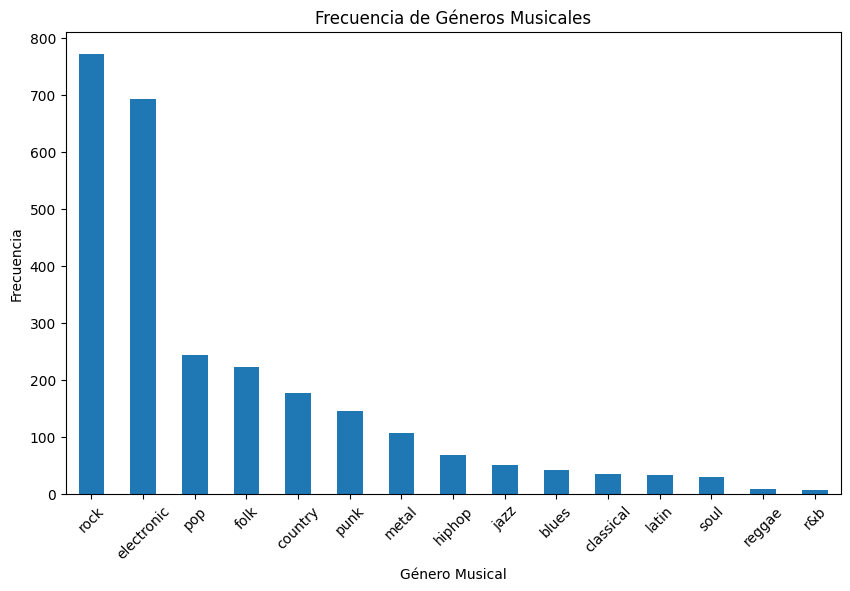

In [82]:
generos_musicales.plot(kind='bar', figsize=(10, 6))
plt.title('Frecuencia de Géneros Musicales')
plt.xlabel('Género Musical')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [83]:
df_artists

,artist_id,artist_name,genre
0,1000004,'Til Tuesday,electronic
1,1000006,.38 Special,pop
2,1000012,"10,000 Maniacs",metal
3,1000023,10cc,electronic
4,1000026,112,electronic
...,...,...,...
2626,1099513,The Darkness,metal
2627,1099605,The Sleepy Jackson,folk
2628,1099693,The Thrills,rock
2629,1100044,Beloved [US],pop


Tenemos un total de `2631` artistas distintos y solamente `15` géneros musicales diferentes. Los que tienen mayor frecuencia en nuestra bbdd es `rock`	con `773`, `electronic` con	`693`, `pop` con `244` y `folk`con	`222`. Los otros géneros musicales tienen menos de `200` observaciones, siendo los que tienen frecuencias menores los  géneros de `soul` con	`29`, `reggae` con	`8`y `r&b`	con `6`. Me llamó mucho la atención que `latin` también tenga poco más de 30 observaciones.

## Análisis del set de datos: `df_train_music`




Lo primero que realizaré es como ya está cargada la bbdd es ver la configuración de los datos y si tenemos algunos faltantes o transformaciones que puedan ser necesarias

In [84]:
df_train_music

,user_id,artist_id,rating
0,643947,1098682,62
1,784415,1068684,0
2,595120,1024523,100
3,1270239,1021824,0
4,735673,1019857,0
...,...,...,...
534632,1248788,1001649,0
534633,103798,1006535,0
534634,1248788,1013581,10
534635,1248788,1016358,14


In [85]:
df_train_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534637 entries, 0 to 534636
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    534637 non-null  int64
 1   artist_id  534637 non-null  int64
 2   rating     534637 non-null  int64
dtypes: int64(3)
memory usage: 12.2 MB


In [86]:
df_train_music.isnull().sum()

,0
user_id,0
artist_id,0
rating,0


Con esto confirmamos la cantidad de datos, tenemos id de usuarios, id de artistas y rating. Tenemos un total de 534637 por columna en el DF y no tenemos datos nulos en `df_train_music`



In [87]:
df_train_music.describe()

,user_id,artist_id,rating
count,5.346370e+05,5.346370e+05,534637.000000
mean,9.514221e+05,1.030821e+06,19.771927
std,5.609952e+05,2.839402e+04,34.829398
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011139e+06,0.000000
50%,9.454190e+05,1.022601e+06,0.000000
75%,1.429002e+06,1.036736e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [88]:
df_train_music['rating'].unique()

array([ 62,   0, 100,  40,  30,  56, 255,  70,  50,  59,  28,  46,  20,
        10,   2,  38,  90,  23,  78,  85,   1,  80,  21,  47,  72,   5,
        97,  60,  92,  48,  71,   4,   7,  32,  88,  67,  79,  83,   6,
        82,  39,   3,  19,  87,  69,   8,  74,  75,  84,  36,  89,  35,
        18,  45,  65,  22,  27,  15,  91,  16,  12,  43,  76,  26,  41,
        86,   9,  64,  49,  68,  95,  37,  58,  55,  96,  14,  13,  61,
        63,  53,  25,  24,  17,  34,  66,  73,  81,  52,  57,  42,  54,
        94,  44,  51,  31,  93,  77,  11,  98,  99,  29,  33])

In [89]:
rating_counts = df_train_music['rating'].value_counts().sort_index()
rating_counts

,count
rating,
0,334327
1,4530
2,1312
3,859
4,1112
...,...
97,127
98,428
99,169


In [90]:
534637 - 334327

200310

In [91]:
334327/534637

0.6253345728036032

In [92]:
numero_users = df_train_music['user_id'].nunique()
numero_users

2549

In [93]:
numero_artistas = df_train_music['artist_id'].nunique()
numero_artistas

2631

In [94]:
todos_artistas_ids = set(df_train_music['artist_id'].unique())

artistas_con_ratings = set(df_train_music['artist_id'].unique())

artistas_no_ratings = todos_artistas_ids - artistas_con_ratings

print(f"Total artistas en catálogo: {len(todos_artistas_ids)}")
print(f"Artistas con al menos una evaluación: {len(artistas_con_ratings)}")
print(f"Artistas sin NINGUNA evaluación: {len(artistas_no_ratings)}")

Total artistas en catálogo: 2631
Artistas con al menos una evaluación: 2631
Artistas sin NINGUNA evaluación: 0


In [95]:
todos_usuarios_ids = set(df_train_music['user_id'].unique())

usuarios_con_ratings = set(df_train_music['user_id'].unique())

usuarios_no_ratings = todos_usuarios_ids - usuarios_con_ratings

print(f"Total usuarios en catálogo: {len(todos_usuarios_ids)}")
print(f"Usuarios con al menos una evaluación: {len(usuarios_con_ratings)}")
print(f"Usuarios sin NINGUNA evaluación: {len(usuarios_no_ratings)}")

Total usuarios en catálogo: 2549
Usuarios con al menos una evaluación: 2549
Usuarios sin NINGUNA evaluación: 0


Los primeros análisis con `df_train_music.describe()`nos muestra que tenemos una gran cantidad de valores en cero, porque en `rating` los valores `min`, `25`y `50`están co valor 0
Luego con `df_train_music['rating'].value_counts().sort_index()`conté cuantos valores tenemos de cada rating único y nos podemos dar cuenta que el valor 0 efectivamente tiene un número importante, este es de un `62.5%` de los valores del dataframe `usuario`, `artista` y `rating`.
Este fenómeno de sparsity significativo es esperable, porque efectivamente los usuarios no consumen todo el catálogo.

El número de usuarios únicos es de 2549 y de artístas únicos es de 2631. De estos todos los artístas y usuarios tienen  evaluaciones.

In [96]:
artist_popularity = df_train_music['artist_id'].value_counts().reset_index()
artist_popularity.columns = ['artist_id', 'conteo_evaluaciones']

artist_popularity_named = artist_popularity.merge(df_artists, on='artist_id', how='left')

In [97]:
top_5_mas = artist_popularity_named.head(5)
print("Top 5 Artistas con MÁS evaluaciones")
print(top_5_mas[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MÁS evaluaciones
           artist_name  genre  conteo_evaluaciones
0  Stone Temple Pilots   rock                  383
1         Eric Clapton   rock                  370
2            Foreigner   rock                  363
3               Eagles   rock                  361
4            Metallica  metal                  361


In [98]:
top_5_menos = artist_popularity_named.tail(5)
print("Top 5 Artistas con MENOS evaluaciones")
print(top_5_menos[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MENOS evaluaciones
           artist_name       genre  conteo_evaluaciones
2626              Snot  electronic                  103
2627        Olga Tanon        folk                  103
2628  Neville Brothers        rock                  102
2629        Tom Lehrer        rock                  100
2630    Steve Ferguson        rock                   98


Con estos dos últimos códigos podemos ver que ningún artísta tiene más de 383 evaluaciones `Stone Temple Pilots` y ninguno menos de 98 `Steve Ferguson`

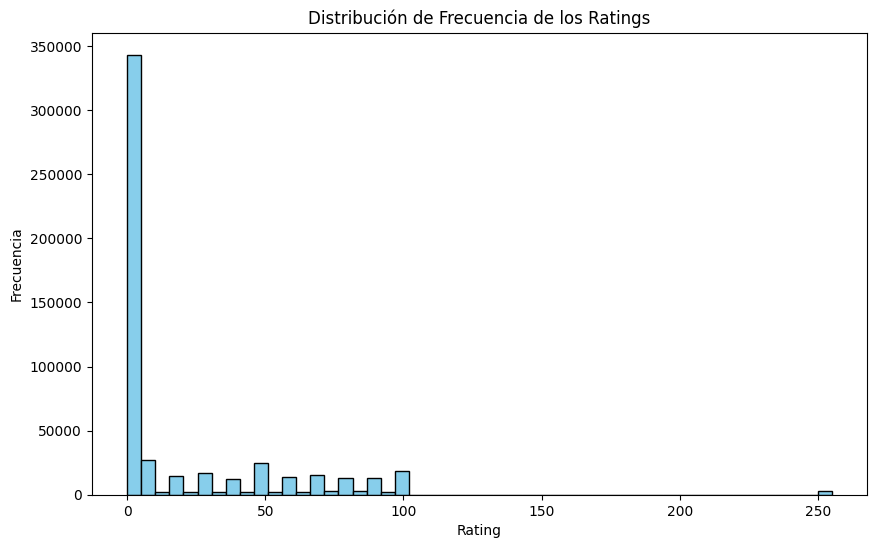

In [99]:
plt.figure(figsize=(10, 6))
plt.hist(df_train_music['rating'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de los Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

In [100]:
print(np.sort(df_train_music['rating'].unique()))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 255]


In [101]:
print((df_train_music['rating'] == 255).sum())

2759


In [102]:
print((df_train_music['rating'] == 100).sum())

17431


In [103]:
2759/534637

0.0051605107764707645

Con esto me di cuenta que tenemos un valor que parece atípico. Un `0.0051605107764707645%` de los valores tienen un valor 255 que creo no está bien porque el rating parece ser de 0 a 100. Por el momento no voy a tomar una decisión de qué hacer con esos datos, porque todavía no hago el análisis del `df_val_music`

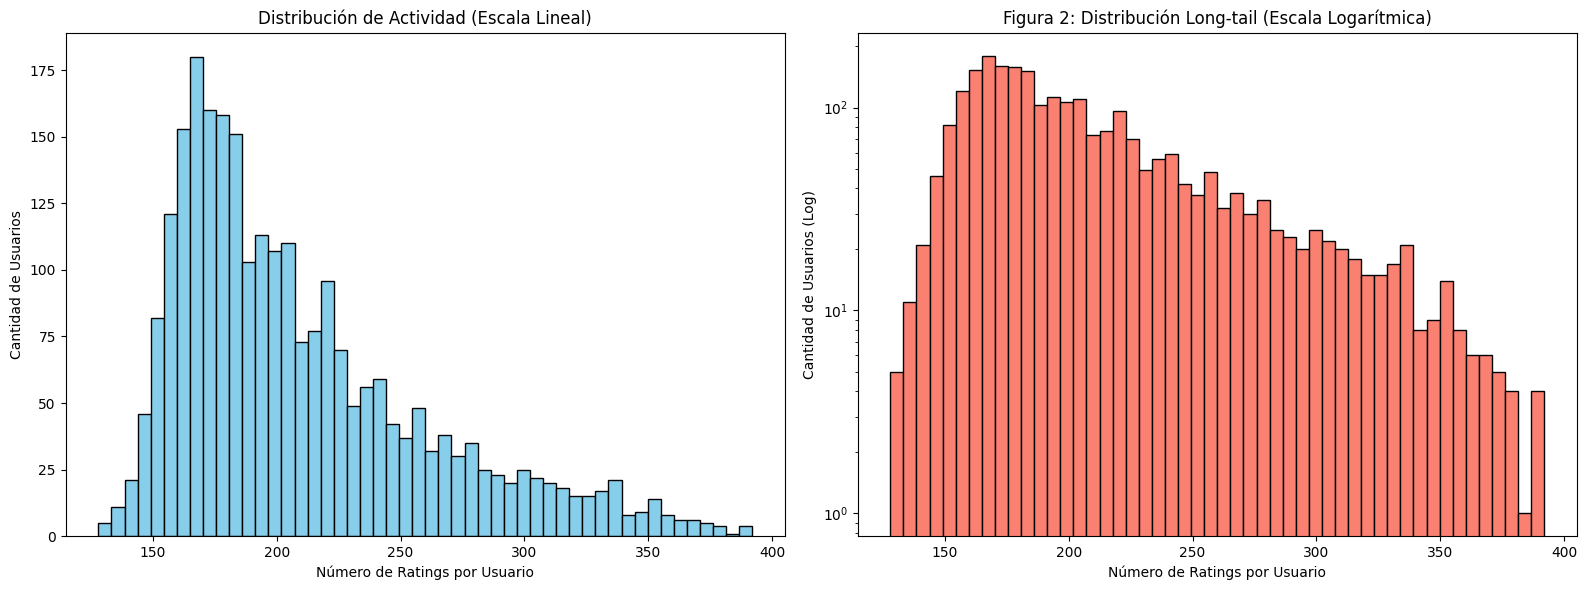

In [104]:
ratings_por_user = df_train_music['user_id'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(ratings_por_user, bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Actividad (Escala Lineal)')
ax1.set_xlabel('Número de Ratings por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')

ax2.hist(ratings_por_user, bins=50, color='salmon', edgecolor='black')
ax2.set_yscale('log')
ax2.set_title('Figura 2: Distribución Long-tail (Escala Logarítmica)')
ax2.set_xlabel('Número de Ratings por Usuario')
ax2.set_ylabel('Cantidad de Usuarios (Log)')

plt.tight_layout()
plt.show()

In [105]:
# Para la tabla de estadísticas
counts = df_train_music['user_id'].value_counts()

print(f"Promedio de ratings por usuario: {counts.mean():.2f}")
print(f"Máximo de ratings por un solo usuario: {counts.max()}")
print(f"Mínimo de ratings por un solo usuario: {counts.min()}")

Promedio de ratings por usuario: 209.74
Máximo de ratings por un solo usuario: 392
Mínimo de ratings por un solo usuario: 128


Este análisis nos demuestra que tenemos casi `210`evaluaciones promedio por usuarios, con un mínimo de `128`y un máximo de `392`evaluaciones por usuario. Por lo menos en este dataset no parece tener el problema de usuarios con muy pocos rating.

In [106]:
n_users_train = df_train_music['user_id'].nunique()
n_items_catalogo = df_artists['artist_id'].nunique()
n_ratings_train = len(df_train_music)

densidad_train = (n_ratings_train / (n_users_train * n_items_catalogo)) * 100

items_por_usuario = n_ratings_train / n_users_train

print(f"--- Análisis de Densidad: Entrenamiento ---")
print(f"Usuarios únicos: {n_users_train}")
print(f"Artistas en catálogo: {n_items_catalogo}")
print(f"Total de Ratings: {n_ratings_train}")
print(f"Promedio de artistas evaluados por usuario: {items_por_usuario:.2f}")
print(f"Densidad del Dataset: {densidad_train:.4f}%")

--- Análisis de Densidad: Entrenamiento ---
Usuarios únicos: 2549
Artistas en catálogo: 2631
Total de Ratings: 534637
Promedio de artistas evaluados por usuario: 209.74
Densidad del Dataset: 7.9720%


La densidad de nuestro set de entrenamiento es de `7.9720%` que indica que aunque la matriz es dispersa y tenemos un número importante de sparsity del `62.5%`.

## Análisis del set de datos: `df_val_music`

Como hice antes comenzaré a revisar la estructura de los datos y si tenemos datos faltantes

In [107]:
df_val_music

,user_id,artist_id,rating
0,1641538,1048320,0
1,1641538,1048942,53
2,1641538,1050886,30
3,930222,1098345,0
4,930222,1020250,0
...,...,...,...
152419,81478,1013119,50
152420,1922878,1009168,20
152421,1711362,1097521,100
152422,1692654,1004539,0


In [108]:
df_val_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152424 entries, 0 to 152423
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    152424 non-null  int64
 1   artist_id  152424 non-null  int64
 2   rating     152424 non-null  int64
dtypes: int64(3)
memory usage: 3.5 MB


In [109]:
df_val_music.isnull().sum()

,0
user_id,0
artist_id,0
rating,0


In [110]:
cantidad_train = 534637
cantidad_val = 152424
total_cantidad_train_val = cantidad_train + cantidad_val
total_cantidad_train_val

687061

In [111]:
534637/687061

0.7781507027760272

In [112]:
152424/687061

0.22184929722397284

Verificamos que no tenemos valores nulos y que al igual que el set de entrenaiento las columnas son exactamente las mismas. La distribución es de un `77.8%`de entrenamiento y un `22.2%`de validación.

In [113]:
df_val_music.describe()

,user_id,artist_id,rating
count,1.524240e+05,1.524240e+05,152424.000000
mean,9.513846e+05,1.030885e+06,19.833051
std,5.609833e+05,2.845525e+04,34.917863
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011312e+06,0.000000
50%,9.454190e+05,1.022740e+06,0.000000
75%,1.429002e+06,1.036607e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [114]:
df_val_music['rating'].unique()

array([  0,  53,  30,   8,  17,  10,  62,  60,  89,  20, 100,  19,   3,
        50,  11,  70,  94,  36,  26,  85,  64,  80,  25,  90,  40,   1,
        52,  76,   2,  61,  81,  68,  59,  54,  45,  67,  79,  63,  57,
        83,  78,  95,  34,  72,  13,  51,  66,  18,  74,  92,  88, 255,
        29,  91,  84,  55,  56,  49,  98,  21,   4,  41,  12,  96,  47,
         7,  75,  58,  14,  77,  82,  28,  48,  38,  35,  65,  87,   5,
        97,  71,  99,  43,  15,  23,  33,  27,  46,   6,  24,  32,  86,
        16,   9,  42,  93,  69,  39,  22,  44,  37,  73,  31])

In [115]:
rating_counts_val = df_val_music['rating'].value_counts().sort_index()
rating_counts_val

,count
rating,
0,95223
1,1304
2,378
3,233
4,338
...,...
97,41
98,130
99,44


In [116]:
cantidad_val - 95223

57201

In [117]:
95223/cantidad_val

0.6247244528420721

In [118]:
numero_users_val = df_val_music['user_id'].nunique()
numero_users_val

2549

In [119]:
numero_artistas_val = df_val_music['artist_id'].nunique()
numero_artistas_val

2631

In [120]:
todos_artistas_ids_val = set(df_val_music['artist_id'].unique())

artistas_con_ratings_val = set(df_val_music['artist_id'].unique())

artistas_no_ratings_val = todos_artistas_ids_val - artistas_con_ratings_val

print(f"Total artistas en catálogo: {len(todos_artistas_ids_val)}")
print(f"Artistas con al menos una evaluación: {len(artistas_con_ratings_val)}")
print(f"Artistas sin NINGUNA evaluación: {len(artistas_no_ratings_val)}")

Total artistas en catálogo: 2631
Artistas con al menos una evaluación: 2631
Artistas sin NINGUNA evaluación: 0


In [121]:
todos_usuarios_ids_val = set(df_val_music['user_id'].unique())

usuarios_con_ratings_val = set(df_val_music['user_id'].unique())

usuarios_no_ratings_val = todos_usuarios_ids_val - usuarios_con_ratings_val

print(f"Total usuarios en catálogo: {len(todos_usuarios_ids_val)}")
print(f"Usuarios con al menos una evaluación: {len(usuarios_con_ratings_val)}")
print(f"Usuarios sin NINGUNA evaluación: {len(usuarios_no_ratings_val)}")

Total usuarios en catálogo: 2549
Usuarios con al menos una evaluación: 2549
Usuarios sin NINGUNA evaluación: 0


Al igual que el set de entrenamiento tenemos un sparsity de más de un 60% (en este caso de `62.47%` que es muy similar al de entrenamiento).

Al igual que el set anterior no tenemos artistas y usuarios sin evaluaciones.

In [122]:
artist_popularity_val = df_val_music['artist_id'].value_counts().reset_index()
artist_popularity_val.columns = ['artist_id', 'conteo_evaluaciones']

artist_popularity_named_val = artist_popularity_val.merge(df_artists, on='artist_id', how='left')


In [123]:
top_5_mas = artist_popularity_named_val.head(5)
print("Top 5 Artistas con MÁS evaluaciones en set de validación")
print(top_5_mas[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MÁS evaluaciones en set de validación
    artist_name       genre  conteo_evaluaciones
0        Staind       metal                  122
1          A-Ha  electronic                  121
2  Led Zeppelin       metal                  121
3         Jewel  electronic                  119
4     Metallica       metal                  118


In [124]:
top_5_menos = artist_popularity_named_val.tail(5)
print("Top 5 Artistas con MENOS evaluaciones en set de validación")
print(top_5_menos[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MENOS evaluaciones en set de validación
         artist_name      genre  conteo_evaluaciones
2626      Mad Season       punk                   24
2627  Spandau Ballet  classical                   24
2628       Tommy Lee    country                   23
2629     Keith Urban    country                   22
2630     Bobby Brown      blues                   20


\Como este set es más pequeño los números son menores. Por ejemplo en el de entrenamiento el artista con mayor cantidad de rating llegaba a las `383`valoraciones, en cambio en el actual es de `122`siendo un número menor, pero es completamente esperable.

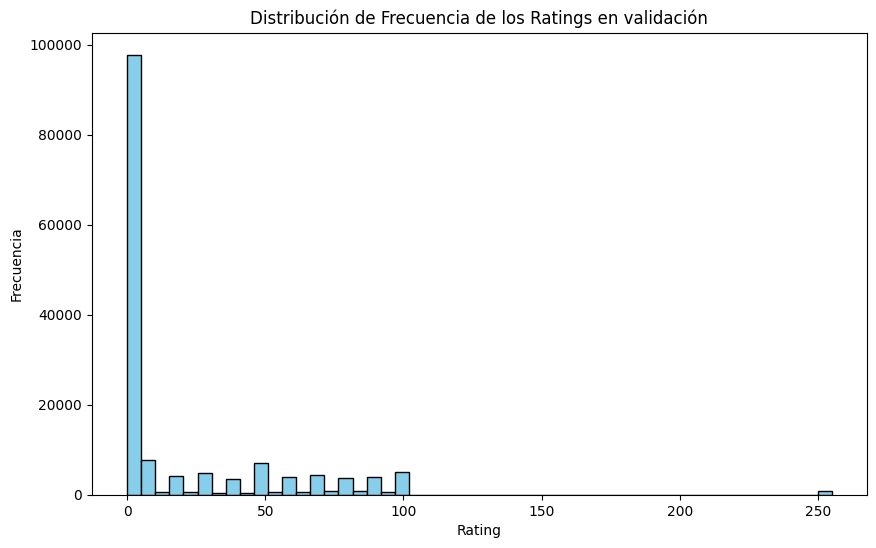

In [125]:
plt.figure(figsize=(10, 6))
plt.hist(df_val_music['rating'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de los Ratings en validación')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

In [126]:
print((df_val_music['rating'] == 255).sum())

794


In [127]:
794/cantidad_val

0.0052091534141604995

Tenemos al igual que en el anterior un grupo de evaluaciones `255` que no parece acorde a los rating de 1 a 100 que parece lo más correcto. Como en ambos sets el número es tan pequeño lo que prefiero es eliminar estos datos para que no afecten el desarrollo de los algoritmos.

In [128]:
# Nuevo set entrenamiento sin valores igual a 255
df_train_music = df_train_music[df_train_music['rating'] != 255].copy().reset_index(drop=True)
df_train_music

,user_id,artist_id,rating
0,643947,1098682,62
1,784415,1068684,0
2,595120,1024523,100
3,1270239,1021824,0
4,735673,1019857,0
...,...,...,...
531873,1248788,1001649,0
531874,103798,1006535,0
531875,1248788,1013581,10
531876,1248788,1016358,14


In [129]:
# Nuevo set validación sin valores igual a 255
df_val_music   = df_val_music[df_val_music['rating'] != 255].copy().reset_index(drop=True)
df_val_music

,user_id,artist_id,rating
0,1641538,1048320,0
1,1641538,1048942,53
2,1641538,1050886,30
3,930222,1098345,0
4,930222,1020250,0
...,...,...,...
151625,81478,1013119,50
151626,1922878,1009168,20
151627,1711362,1097521,100
151628,1692654,1004539,0


Eso sí voy a dejar los mismos gráficos que en el anterior, aunque después voy a hacer todo sin los valores atípicos. El siguiente es espejo del anterior

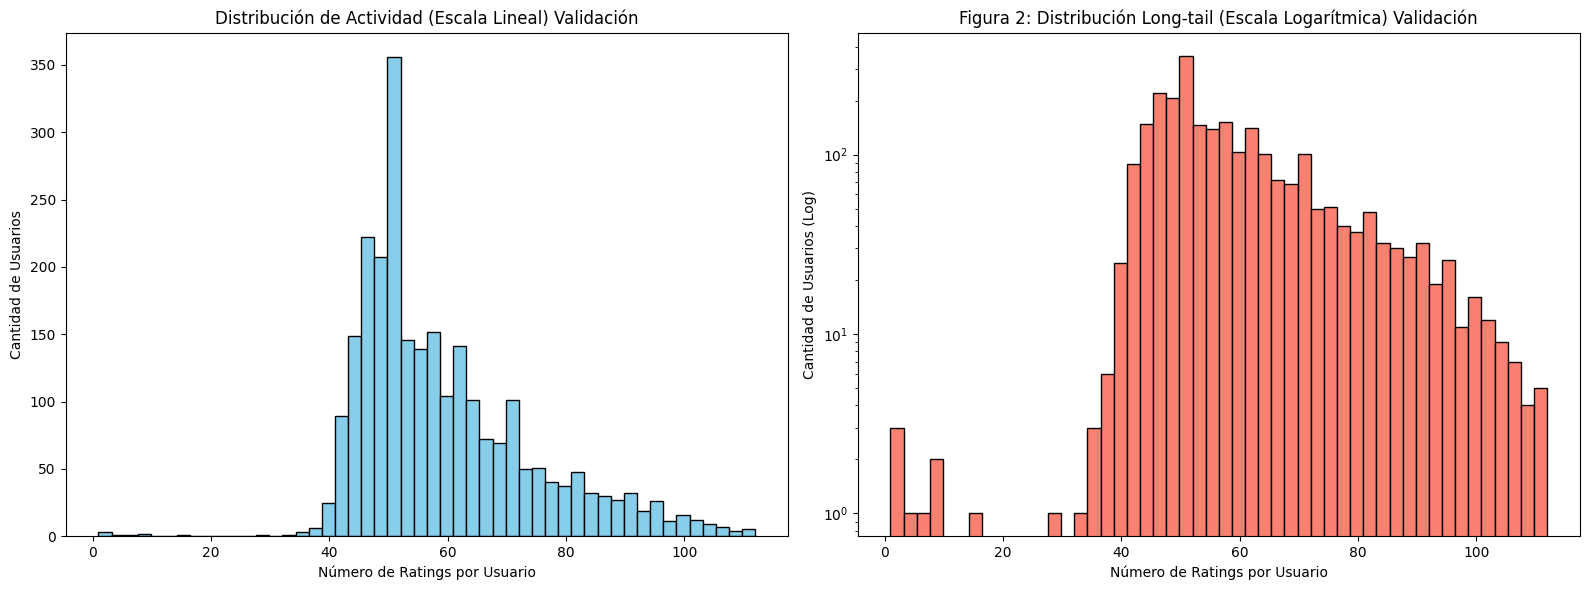

In [130]:
ratings_por_user_val = df_val_music['user_id'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(ratings_por_user_val, bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Actividad (Escala Lineal) Validación')
ax1.set_xlabel('Número de Ratings por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')

ax2.hist(ratings_por_user_val, bins=50, color='salmon', edgecolor='black')
ax2.set_yscale('log')
ax2.set_title('Figura 2: Distribución Long-tail (Escala Logarítmica) Validación')
ax2.set_xlabel('Número de Ratings por Usuario')
ax2.set_ylabel('Cantidad de Usuarios (Log)')

plt.tight_layout()
plt.show()

In [131]:
# Para la tabla de estadísticas
counts_val = df_val_music['user_id'].value_counts()

print(f"Promedio de ratings por usuario validación: {counts_val.mean():.2f}")
print(f"Máximo de ratings por un solo usuario validación: {counts_val.max()}")
print(f"Mínimo de ratings por un solo usuario validación: {counts_val.min()}")

Promedio de ratings por usuario validación: 59.51
Máximo de ratings por un solo usuario validación: 112
Mínimo de ratings por un solo usuario validación: 1


In [132]:
n_users_val = df_val_music['user_id'].nunique()
n_items_catalogo = df_artists['artist_id'].nunique()
n_ratings_val = len(df_val_music)

densidad_val = (n_ratings_val / (n_users_val * n_items_catalogo)) * 100

items_por_usuario_val = n_ratings_val / n_users_val

print(f"--- Análisis de Densidad: Validación ---")
print(f"Usuarios únicos: {n_users_val}")
print(f"Artistas en catálogo: {n_items_catalogo}")
print(f"Total de Ratings: {n_ratings_val}")
print(f"Promedio de artistas evaluados por usuario: {items_por_usuario_val:.2f}")
print(f"Densidad del Dataset: {densidad_val:.4f}%")

--- Análisis de Densidad: Validación ---
Usuarios únicos: 2548
Artistas en catálogo: 2631
Total de Ratings: 151630
Promedio de artistas evaluados por usuario: 59.51
Densidad del Dataset: 2.2619%


Es una densidad menor que el de entrenamiento, creo que era esperable al tener menos datos

Antes de seguir con los algoritmos, voy a cambiar el dataset por el que no tiene los valores atípicos, pero los dejaré con un nombre más simple

In [133]:
df_train = df_train_music
df_val = df_val_music

In [134]:
print(f"Estadísticas Finales (Escala 0-100)")
print(f"Entrenamiento - Average Rating: {df_train['rating'].mean():.2f}")
print(f"Entrenamiento - STD Rating: {df_train['rating'].std():.2f}")
print(f"Validación - Average Rating: {df_val['rating'].mean():.2f}")
print(f"Validación - STD Rating: {df_val['rating'].std():.2f}")

Estadísticas Finales (Escala 0-100)
Entrenamiento - Average Rating: 18.55
Entrenamiento - STD Rating: 30.51
Validación - Average Rating: 18.60
Validación - STD Rating: 30.57


In [135]:
print(f"Máximo actual en Train: {df_train['rating'].max()}")

Máximo actual en Train: 100


In [136]:
print(f"Máximo actual en Train: {df_val['rating'].max()}")

Máximo actual en Train: 100


/tmp/ipykernel_2187/2105930707.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Set', y='rating', data=df_plot, palette='Set2')


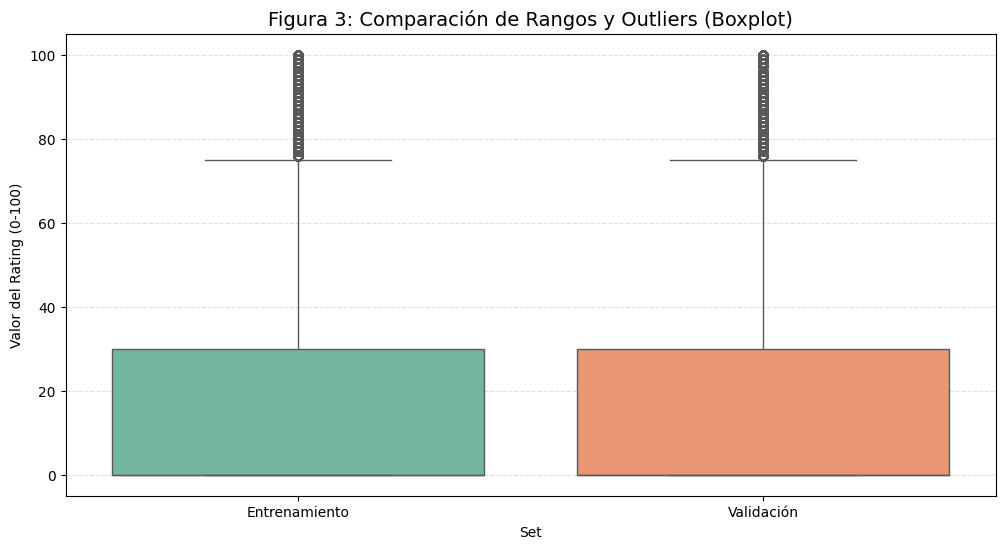

/tmp/ipykernel_2187/2105930707.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Set', y='rating', data=df_plot, palette='Pastel1', inner='quartile')


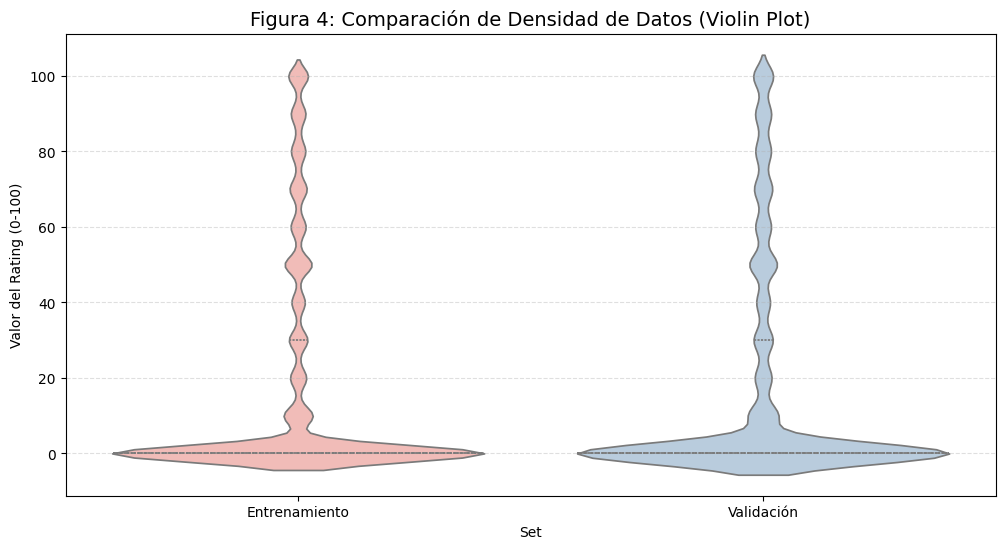

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train['Set'] = 'Entrenamiento'
df_val['Set'] = 'Validación'
df_plot = pd.concat([df_train[['rating', 'Set']], df_val[['rating', 'Set']]])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Set', y='rating', data=df_plot, palette='Set2')
plt.title('Figura 3: Comparación de Rangos y Outliers (Boxplot)', fontsize=14)
plt.ylabel('Valor del Rating (0-100)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(x='Set', y='rating', data=df_plot, palette='Pastel1', inner='quartile')
plt.title('Figura 4: Comparación de Densidad de Datos (Violin Plot)', fontsize=14)
plt.ylabel('Valor del Rating (0-100)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Lo primero que podemos identificar que ambos sets, entrenamiento y validación, son consistentes entre sí, con una estructura estadística muy similar, facilitando su poder de comparación. Obviamente tenemos ambos boxplot comenzando en 0 porque tenemos más de un `60%` de sparsity.  

El de violín nos muestra que los usuarios que entregan resultados lo hacen distribuyendo los puntajes, con notorias concentraciones en puntajes bajo `20`, con un importante grupo en `50`y con un número aunque menor, pero claro con el máximo de puntos.

In [138]:
bins = [-0.1, 0.5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']

df_train['rango'] = pd.cut(df_train['rating'], bins=bins, labels=labels)
res_train = df_train['rango'].value_counts().sort_index().reset_index()
res_train.columns = ['Rango', 'Train_Count']

df_val['rango'] = pd.cut(df_val['rating'], bins=bins, labels=labels)
res_val = df_val['rango'].value_counts().sort_index().reset_index()
res_val.columns = ['Rango', 'Val_Count']

tabla_rangos = pd.merge(res_train, res_val, on='Rango')
tabla_rangos['Train_%'] = (tabla_rangos['Train_Count'] / tabla_rangos['Train_Count'].sum() * 100).round(2)
tabla_rangos['Val_%'] = (tabla_rangos['Val_Count'] / tabla_rangos['Val_Count'].sum() * 100).round(2)

print("Distribución de Ratings por Grupos (0 Aislado)")
display(tabla_rangos)

Distribución de Ratings por Grupos (0 Aislado)


,Rango,Train_Count,Val_Count,Train_%,Val_%
0,0,334327,95223,62.86,62.80
1,1-10,35667,10216,6.71,6.74
2,11-20,16816,4828,3.16,3.18
3,21-30,18849,5360,3.54,3.53
4,31-40,13665,3851,2.57,2.54
5,41-50,26410,7456,4.97,4.92
6,51-60,15260,4323,2.87,2.85
7,61-70,17948,5137,3.37,3.39
8,71-80,15498,4488,2.91,2.96
9,81-90,16845,4883,3.17,3.22


La pregunta tabla explica lo mismo que el gráfico de violín. Tenemos una gran representación de evaluaciones en bajo, intermedio y alto. Esto podría hacernos pensar que si esto fuera con 1 a 5 estrellas podríamos tener valores similares.

# 255 de no volver a escuchar

La primera vez cargué los datos y luego comencé a interpretar, pero luego leí bien las instrucciones y me di cuenta que no era un outlier sino un dato muy característico con un significado de "No volver
a reproducir canción"

Vi que hay una boniticación, pero efectivamente no estoy muy seguro que hacer con esto, en especial porque son muy pocos datos.

La Tabla final de los datos antes de eliminar el valor 255

In [139]:
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)



def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)

In [140]:
print("\n" + "="*60)
print("1. ANÁLISIS DE DATOS - Cuadro 1")
print("="*60)

def dataset_stats(df, name):
    stats = {
        'Number of Users': df['user_id'].nunique(),
        'Number of Items': df['artist_id'].nunique(),
        'Total Ratings': len(df),
        'Avg Ratings per User': round(df.groupby('user_id').size().mean(), 2),
        'Avg Ratings per Item': round(df.groupby('artist_id').size().mean(), 2),
        'Avg Rating': round(df['rating'].mean(), 2),
        'Rating Std': round(df['rating'].std(), 2),
        'Max Ratings per User': df.groupby('user_id').size().max(),
        'Max Ratings per Item': df.groupby('artist_id').size().max(),
        'Density (%)': round(len(df) / (df['user_id'].nunique() * df['artist_id'].nunique()) * 100, 3)
    }
    return pd.Series(stats, name=name)

stats_train = dataset_stats(df_train_music, 'Training')
stats_val   = dataset_stats(df_val_music, 'Validation')
cuadro1 = pd.concat([stats_train, stats_val], axis=1)
display(cuadro1)


1. ANÁLISIS DE DATOS - Cuadro 1


,Training,Validation
Number of Users,2549.000,2549.000
Number of Items,2631.000,2631.000
Total Ratings,534637.000,152424.000
Avg Ratings per User,209.740,59.800
Avg Ratings per Item,203.210,57.930
Avg Rating,19.770,19.830
Rating Std,34.830,34.920
Max Ratings per User,392.000,112.000
Max Ratings per Item,383.000,122.000
Density (%),7.972,2.273


Ahora con una nueva estrategia del valor 255 que es incorporándolo al cero, total las personas si o quieren escucharlo es como calificarlo con cero

In [141]:
print("\nRatings 255 encontrados:")
print(f"   Train: {(df_train_music['rating'] == 255).sum():,}")
print(f"   Val:   {(df_val_music['rating'] == 255).sum():,}")

df_train_music['rating'] = df_train_music['rating'].replace(255, 0)
df_val_music['rating']   = df_val_music['rating'].replace(255, 0)

print("→ Rating 255 reemplazado por 0 (señal negativa explícita)")
print(f"→ Escala final: 0 a 100\n")

reader = Reader(rating_scale=(0, 100))


Ratings 255 encontrados:
   Train: 2,759
   Val:   794
→ Rating 255 reemplazado por 0 (señal negativa explícita)
→ Escala final: 0 a 100



In [142]:
print("\n" + "="*60)
print("1. ANÁLISIS DE DATOS - Cuadro 2")
print("="*60)

def dataset_stats(df, name):
    stats = {
        'Number of Users': df['user_id'].nunique(),
        'Number of Items': df['artist_id'].nunique(),
        'Total Ratings': len(df),
        'Avg Ratings per User': round(df.groupby('user_id').size().mean(), 2),
        'Avg Ratings per Item': round(df.groupby('artist_id').size().mean(), 2),
        'Avg Rating': round(df['rating'].mean(), 2),
        'Rating Std': round(df['rating'].std(), 2),
        'Max Ratings per User': df.groupby('user_id').size().max(),
        'Max Ratings per Item': df.groupby('artist_id').size().max(),
        'Density (%)': round(len(df) / (df['user_id'].nunique() * df['artist_id'].nunique()) * 100, 3)
    }
    return pd.Series(stats, name=name)

stats_train = dataset_stats(df_train_music, 'Training')
stats_val   = dataset_stats(df_val_music, 'Validation')
cuadro2 = pd.concat([stats_train, stats_val], axis=1)
display(cuadro1)


1. ANÁLISIS DE DATOS - Cuadro 2


,Training,Validation
Number of Users,2549.000,2549.000
Number of Items,2631.000,2631.000
Total Ratings,534637.000,152424.000
Avg Ratings per User,209.740,59.800
Avg Ratings per Item,203.210,57.930
Avg Rating,19.770,19.830
Rating Std,34.830,34.920
Max Ratings per User,392.000,112.000
Max Ratings per Item,383.000,122.000
Density (%),7.972,2.273


# Recomendaciones
Trabajé los modelos con Surprise para hacerlo todo con la misma biblioteca

In [151]:
!pip install codecarbon -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 134.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 133.3 MB/s eta 0:00:00


In [152]:
# Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy
from codecarbon import EmissionsTracker

In [166]:
# Preparar variables para Surprise
reader   = Reader(rating_scale=(0, 100))
data     = Dataset.load_from_df(df_train_music[['user_id', 'artist_id', 'rating']], reader)
trainset = data.build_full_trainset()

train_pairs = set(
    zip(df_train_music['user_id'].astype(str),
        df_train_music['artist_id'].astype(str))
)

testset = [
    (str(uid), str(iid), float(r))
    for uid, iid, r in df_val_music[['user_id', 'artist_id', 'rating']].to_numpy()
    if (str(uid), str(iid)) not in train_pairs
]

print(f"Trainset: {trainset.n_ratings:,} ratings")
print(f"Testset:  {len(testset):,} ratings\n")

Trainset: 534,637 ratings
Testset:  152,424 ratings



In [145]:
# Métricas
def get_top_n(predictions, n=10):
    """Genera top-N recomendaciones por usuario."""
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

def recall_at_k(predictions, k=10, threshold=50):
    """Recall@K: fracción de ítems relevantes que fueron recomendados."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, float(true_r)))

    recalls = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel       = sum(1 for (_, r) in user_ratings if r >= threshold)
        n_rec_k     = sum(1 for (_, r) in user_ratings[:k] if r >= threshold)
        if n_rel > 0:
            recalls.append(n_rec_k / n_rel)
    return round(np.mean(recalls), 4) if recalls else 0.0

def ndcg_at_k(predictions, k=10, threshold=50):
    """nDCG@K."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, float(true_r)))

    ndcgs = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k    = user_ratings[:k]
        dcg      = sum((1 if r >= threshold else 0) / math.log2(i + 2)
                       for i, (_, r) in enumerate(top_k))
        ideal    = sorted([r for (_, r) in user_ratings], reverse=True)[:k]
        idcg     = sum((1 if r >= threshold else 0) / math.log2(i + 2)
                       for i, r in enumerate(ideal))
        if idcg > 0:
            ndcgs.append(dcg / idcg)
    return round(np.mean(ndcgs), 4) if ndcgs else 0.0

def map_at_k(predictions, k=10, threshold=50):
    """MAP@K."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, float(true_r)))

    aps = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        hits, precision_sum = 0, 0.0
        for i, (_, r) in enumerate(top_k):
            if r >= threshold:
                hits += 1
                precision_sum += hits / (i + 1)
        n_rel = sum(1 for (_, r) in user_ratings if r >= threshold)
        if n_rel > 0:
            aps.append(precision_sum / min(n_rel, k))
    return round(np.mean(aps), 4) if aps else 0.0

def diversidad(top_n_dict, artist_genres):
    """Géneros distintos promedio por lista de recomendación."""
    divs = []
    for uid, items in top_n_dict.items():
        genres = set(artist_genres.get(int(iid), 'Unknown') for iid, _ in items)
        divs.append(len(genres))
    return round(np.mean(divs), 4) if divs else 0.0

def novedad(top_n_dict, item_popularity, n_users):
    """Self-information promedio de las listas."""
    novs = []
    for uid, items in top_n_dict.items():
        nov = sum(-math.log2(item_popularity.get(int(iid), 1e-10))
                  for iid, _ in items)
        novs.append(nov / len(items) if items else 0)
    return round(np.mean(novs), 4) if novs else 0.0

In [146]:
# Preparar diccionarios para diversidad y novedad
artist_genres   = dict(zip(df_artists['artist_id'], df_artists['genre']))
item_counts     = df_train_music['artist_id'].value_counts()
n_users_train   = df_train_music['user_id'].nunique()
item_popularity = (item_counts / n_users_train).to_dict()

In [147]:
def evaluar_modelo(model, trainset, testset, top_n_dict=None, nombre="Modelo"):
    """Evalúa RMSE, MAE, Recall@10, nDCG@10, MAP@10, Diversidad, Novedad."""
    predictions = model.test(testset)
    rmse = round(accuracy.rmse(predictions, verbose=False), 4)
    mae  = round(accuracy.mae(predictions, verbose=False), 4)
    r10  = recall_at_k(predictions, k=10)
    n10  = ndcg_at_k(predictions, k=10)
    m10  = map_at_k(predictions, k=10)

    # Para diversidad y novedad necesitamos el anti_testset
    a_testset    = trainset.build_anti_testset()
    a_predictions = model.test(a_testset)
    top_n        = get_top_n(a_predictions, n=10)
    div          = diversidad(top_n, artist_genres)
    nov          = novedad(top_n, item_popularity, n_users_train)

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  RMSE:        {rmse}")
    print(f"  MAE:         {mae}")
    print(f"  Recall@10:   {r10}")
    print(f"  nDCG@10:     {n10}")
    print(f"  MAP@10:      {m10}")
    print(f"  Diversidad:  {div}")
    print(f"  Novedad:     {nov}")

    return {
        'Método': nombre, 'RMSE': rmse, 'MAE': mae,
        'Recall@10': r10, 'nDCG@10': n10, 'MAP@10': m10,
        'Diversidad': div, 'Novedad': nov
    }

In [148]:
# Lista para guardar los resultados
resultados = []

In [155]:
import os

#Preparar carpeta para emisiones

os.makedirs("./emissions", exist_ok=True)

In [167]:
print("\nEntrenando UserKNN...")
tracker = EmissionsTracker(project_name="UserKNN", output_dir="./emissions", log_level="error")
tracker.start()

userKNN = KNNBasic(k=40, sim_options={'name': 'pearson', 'user_based': True})
userKNN.fit(trainset)

tracker.stop()
res = evaluar_modelo(userKNN, trainset, testset, nombre="UserKNN (k=40, pearson)")
resultados.append(res)


Entrenando UserKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.

  UserKNN (k=40, pearson)
  RMSE:        30.5197
  MAE:         24.7716
  Recall@10:   0.1806
  nDCG@10:     0.266
  MAP@10:      0.1739
  Diversidad:  2.8148
  Novedad:     3.0698


In [ ]:
print("\nEntrenando ItemKNN...")
tracker = EmissionsTracker(project_name="ItemKNN", output_dir="./emissions", log_level="error")
tracker.start()

itemKNN = KNNBasic(k=40, sim_options={'name': 'pearson', 'user_based': False})
itemKNN.fit(trainset)

tracker.stop()
res = evaluar_modelo(itemKNN, trainset, testset, nombre="ItemKNN (k=40, pearson)")
resultados.append(res)


Entrenando ItemKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.


In [ ]:
print("\nEntrenando FunkSVD...")
tracker = EmissionsTracker(project_name="FunkSVD", output_dir="./emissions", log_level="error")
tracker.start()

funkSVD = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)
funkSVD.fit(trainset)

tracker.stop()
res = evaluar_modelo(funkSVD, trainset, testset, nombre="FunkSVD (f=50, lr=0.005)")
resultados.append(res)

In [ ]:
print("\n\n" + "="*60)
print("CUADRO 2 - Comparación de Métodos")
print("="*60)
df_resultados = pd.DataFrame(resultados).set_index('Método')
display(df_resultados)

In [ ]:
print("\nAnálisis de sensibilidad: K en ItemKNN...")
k_values  = [10, 40, 80]
sens_knn  = []

for k in k_values:
    m = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': False})
    m.fit(trainset)
    preds = m.test(testset)
    sens_knn.append({
        'k': k,
        'RMSE': round(accuracy.rmse(preds, verbose=False), 4),
        'MAE':  round(accuracy.mae(preds, verbose=False), 4),
    })

df_sens_knn = pd.DataFrame(sens_knn)
print(df_sens_knn)

plt.figure(figsize=(8, 4))
plt.plot(df_sens_knn['k'], df_sens_knn['RMSE'], marker='o', label='RMSE')
plt.plot(df_sens_knn['k'], df_sens_knn['MAE'],  marker='s', label='MAE')
plt.title('Sensibilidad de K en ItemKNN')
plt.xlabel('Número de vecinos K')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("\nAnálisis de sensibilidad: factores latentes en FunkSVD...")
factor_values = [10, 50, 100]
sens_svd      = []

for f in factor_values:
    m = SVD(n_factors=f, n_epochs=20, lr_all=0.005, reg_all=0.02)
    m.fit(trainset)
    preds = m.test(testset)
    sens_svd.append({
        'n_factors': f,
        'RMSE': round(accuracy.rmse(preds, verbose=False), 4),
        'MAE':  round(accuracy.mae(preds, verbose=False), 4),
    })

df_sens_svd = pd.DataFrame(sens_svd)
print(df_sens_svd)

plt.figure(figsize=(8, 4))
plt.plot(df_sens_svd['n_factors'], df_sens_svd['RMSE'], marker='o', label='RMSE')
plt.plot(df_sens_svd['n_factors'], df_sens_svd['MAE'],  marker='s', label='MAE')
plt.title('Sensibilidad de Factores Latentes en FunkSVD')
plt.xlabel('Número de factores latentes')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os, glob

emission_files = glob.glob('./emissions/emissions*.csv')
if emission_files:
    df_em = pd.concat([pd.read_csv(f) for f in emission_files], ignore_index=True)
    print("\nEmisiones CO2e por modelo:")
    display(df_em[['project_name', 'duration', 'emissions', 'energy_consumed']])

In [ ]:
import requests
import json
import pandas as pd


rating_url = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/refs/heads/main/data/competicion_rating.txt"
df_comp_rating = pd.read_csv(rating_url, names=['user_id', 'artist_id', 'rating'])
print(f"competicion_rating: {len(df_comp_rating):,} filas")
print(df_comp_rating.head())

ranking_url = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/refs/heads/main/data/competicion_ranking.json"
comp_ranking = requests.get(ranking_url).json()
print(f"\ncompeticion_ranking: {len(comp_ranking)} usuarios")
print("Ejemplo clave:", list(comp_ranking.keys())[:3])

In [ ]:
a_testset     = trainset.build_anti_testset()
a_predictions = funkSVD.test(a_testset)
top10         = get_top_n(a_predictions, n=10)

for uid_str in comp_ranking.keys():
    uid_key = str(uid_str)
    recomendados = top10.get(uid_key) or top10.get(int(uid_key), [])

    if recomendados:
        comp_ranking[uid_str] = [int(iid) for iid, _ in recomendados]
    else:
        comp_ranking[uid_str] = most_popular[:10]

with open('competicion_ranking.json', 'w') as f:
    json.dump(comp_ranking, f)

print(f"competicion_ranking.json guardado")
print(f"   Ejemplo usuario {list(comp_ranking.keys())[0]}: {list(comp_ranking.values())[0]}")

In [ ]:
from google.colab import files
files.download('competicion_rating.txt')
files.download('competicion_ranking.json')